# Data Pipelines & Data Analytics Lifecycle
# Forecasting the Wind Power Production in Orkney

## Introduction

In this assignment you will play the role of a Data Scientist consultant for the Scottish and Southern Electricity Networks (SSEN). Among many other areas, the SSEN provides electricity for the Okrney islands, in Northern Scottland. This archipelago has significant wind and marine energy resources, and it generates over 100% of its 
net power from renewable sources, coming mainly from wind turbines situated across Orkney. This is good news for Orkney and the environment, but although wind farms provide emissions-free energy, they only generate electricity when the wind blows.

Your job? To design and implement a training pipeline, including data preprocessing, evaluation and model storing, for a small wind energy forecasting system. The goal here is to use weather forecasting data to predict the energy production for Orkney. You will need all your data scientist skills for insights, and you will have 
some libraries at your disposal, such as Scikit-Learn and MLFlow (and as many others as you might need). This Jupyter Notebook will help you started.

The steps you will complete in this project are:

- align the datasets
- create pipelines for preprocessing and prediction
- compare your pipelines with MLflow Tracking
- register your best model with MLflow Registry
- serve the best model
- package the project using MLProjects

Above this cell you will find an *Outline* button. Click it and an outline of this notebook should appear on the left bottom corner of the screen. This will help you navigate to a specific section.

**Dependencies**

If you've just created this workspace, install mlflow by typing the command below in the Terminal. If you already did this in a previous session, there is no need to install it again.

```
pip install mlflow
```

Now let's import all libraries necessary for this project.
The first time you will run a cell in this notebook, a dialogue box will appear asking if you want to Install/enable suggested extentions: python and jupyter. Go ahead and once that is finished select the created kernel.

In [1]:
import mlflow

# You will probably need these
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.pipeline import Pipeline

# This are for example purposes. You may discard them if you don't use them.
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score, ParameterGrid
from sklearn.metrics import mean_absolute_error, mean_squared_error, explained_variance_score, r2_score, make_scorer
from mlflow.models import infer_signature
from urllib.parse import urlparse

### TODO -> HERE YOU CAN ADD ANY OTHER LIBRARIES YOU MAY NEED ###
from scipy.stats import zscore
from sklearn.base import BaseEstimator, TransformerMixin
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, make_scorer


<a name="data"></a> 

## Data exploration

You will work with three datasets:

**Power generation data** (`power.csv`)

* *Source:* Scottish and Southern Electricity Networks (SSEN)
* *Granularity:* 1-minute sampling
* *Target variable:* Total renewable power generation (MW)

Key fields:

* `time`: Timestamp of measurement
* `Total`: Renewable power generation (MW)

**Weather forecast data** (`weather.csv`)

* *Source:* UK Met Office
* *Granularity:* 3-hour intervals
* Forecasts include a *source time* (forecast creation) and a *target time* (forecasted timestamp)

Key fields:

* `time`: Target time of the forecast
* `Speed`: Wind speed (m/s)
* `Direction`: Wind direction (categorical string, e.g. "NW")
* `Source_time`: Forecast generation time
* `Lead_hours`: Forecast horizon

**Future forecasts** (`future.csv`)

* Weather forecasts to be used for generating future power predictions using your model

Let's first load the first 2 datasets.

In [2]:
power_df = pd.read_csv('data/power.csv', parse_dates=["time"], index_col="time")
wind_df = pd.read_csv('data/weather.csv', parse_dates=["time"], index_col="time")

In [4]:
power_df.index.is_monotonic_increasing
wind_df.index.is_monotonic_increasing
# true - time series data - correct ordering

True

In [5]:
power_df.index.duplicated().sum()
wind_df.index.duplicated().sum()
# 0 = zero duplicates

np.int64(0)

In [6]:
power_df.index.to_series().diff().value_counts().head() # shows the distribution of time GAPS between consecutive timestamps, not the timestamps themselves
# so i.e. we have 106104:   1 minute gaps
# and i.e. 1053:  2 minute gaps
# ---> a LOT of missing vmeasurements (rows)


time
0 days 00:01:00    106104
0 days 00:02:00      1053
0 days 00:03:00       575
0 days 00:04:00       375
0 days 00:05:00       264
Name: count, dtype: int64

In [7]:
wind_df.index.to_series().diff().value_counts()
# just (12 ---> 3) + (6 ---> 1) = 4 missing measured information - like 4 missing measures

time
0 days 03:00:00    713
0 days 12:00:00      1
0 days 06:00:00      1
Name: count, dtype: int64

In [8]:
# let's check the missing values
power_df.isna().sum()
wind_df.isna().sum()
# we have zero missing values

Direction      0
Lead_hours     0
Source_time    0
Speed          0
dtype: int64

<Axes: xlabel='time'>

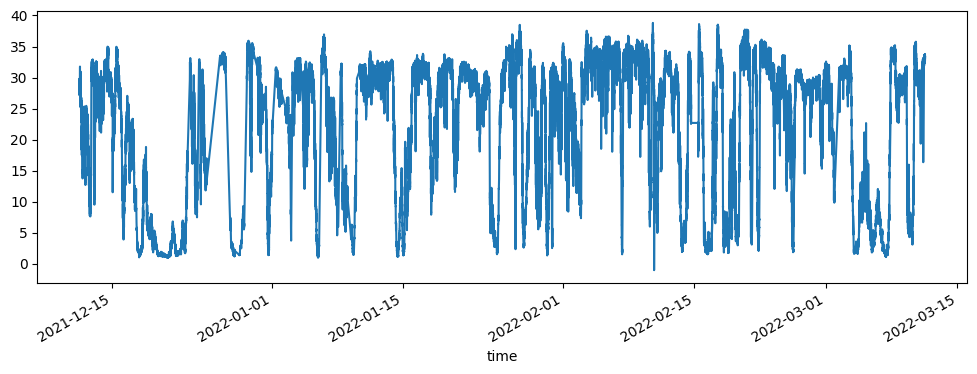

In [9]:
power_df["Total"].plot(figsize=(12,4))

<Axes: xlabel='time'>

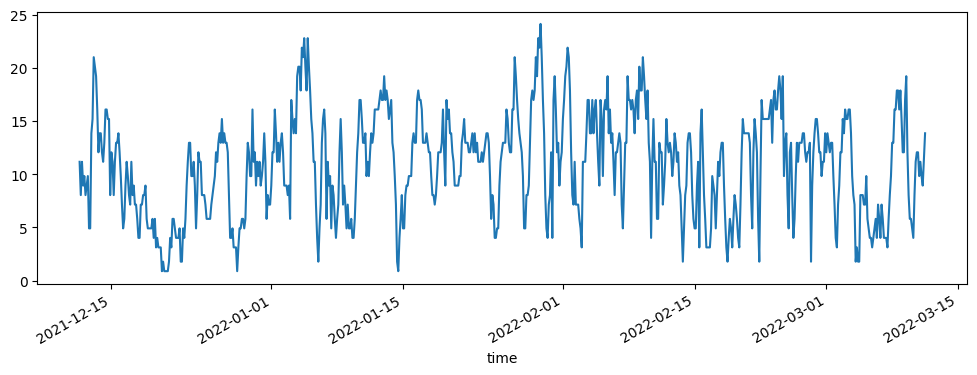

In [10]:
wind_df["Speed"].plot(figsize=(12,4))

Let's take a look at the resulting dataframes:

In [11]:
power_df.head()

,ANM,Non-ANM,Total
time,,,
2021-12-11 13:39:00+00:00,10.195558,17.102,27.297558
2021-12-11 13:40:00+00:00,10.043559,17.582,27.625559
2021-12-11 13:41:00+00:00,10.961558,17.139,28.100558
2021-12-11 13:42:00+00:00,11.240559,16.194,27.434559
2021-12-11 13:43:00+00:00,10.672559,16.566,27.238559


This table contains three columns, but closer inspection will reveal a clear relationship between those three. Can you spot that?

We are interested in the total power generation, regardless of the source type. Modify the table such that only the column of interest is kept.

In [12]:
power_df = power_df.drop(columns = ['ANM', 'Non-ANM'])
power_df.head()

,Total
time,
2021-12-11 13:39:00+00:00,27.297558
2021-12-11 13:40:00+00:00,27.625559
2021-12-11 13:41:00+00:00,28.100558
2021-12-11 13:42:00+00:00,27.434559
2021-12-11 13:43:00+00:00,27.238559


In [13]:
wind_df.head()

,Direction,Lead_hours,Source_time,Speed
time,,,,
2021-12-11 15:00:00+00:00,SSE,1,1639227600,11.17600
2021-12-11 18:00:00+00:00,SSW,1,1639238400,8.04672
2021-12-11 21:00:00+00:00,WSW,1,1639249200,11.17600
2021-12-12 00:00:00+00:00,WSW,1,1639260000,8.94080
2021-12-12 03:00:00+00:00,SW,1,1639270800,9.83488


This table contains four columns, but lead hours and source time are irrelevant here. Can you think why?


In [ ]:
# 'Lead_hours' and 'Source_time' are irrelevant because they describe the forecast process, not the physical weather conditions at the target time.
#wind_df = wind_df.drop(columns=['Lead_hours', 'Source_time'])
print(wind_df.head())

'''
What Actually Matters for Power Generation?

Our target variable is:
--> Total renewable generation (MW) at time t

What physically affects wind power at time t?
- Wind Speed
- Wind Direction
- (other weather variables if available)

These are properties of the atmosphere at the target time.

While 'Lead_hours' = how far ahead the forecast was made
Example:
    - Lead_hours = 1 → forecast made 1 hour before target time
    - Lead_hours = 24 → forecast made 24 hours before

But:
- At 2021-12-11 15:00, the wind either blew at 11.176 m/s or it didn’t.

The turbine doesn’t care whether:
- The forecast was made 1 hour before
- Or 24 hours before
--> It only cares about the actual wind at that time.


And while 'Source_time' = When the forecast was generated (Unix timestamp)
--> It exists because meteorological systems issue forecasts at specific times.

But again:
Power generation at 15:00 depends on:
- Wind speed at 15:00
- Wind direction at 15:00

It does not depend on:
- When the forecast was created
--> So Source_time contains no physical signal about wind conditions.
'''

                          Direction     Speed
time                                         
2021-12-11 15:00:00+00:00       SSE  11.17600
2021-12-11 18:00:00+00:00       SSW   8.04672
2021-12-11 21:00:00+00:00       WSW  11.17600
2021-12-12 00:00:00+00:00       WSW   8.94080
2021-12-12 03:00:00+00:00        SW   9.83488


"\nWhat Actually Matters for Power Generation?\n\nOur target variable is:\n--> Total renewable generation (MW) at time t\n\nWhat physically affects wind power at time t?\n- Wind Speed\n- Wind Direction\n- (other weather variables if available)\n\nThese are properties of the atmosphere at the target time.\n\nWhile 'Lead_hours' = how far ahead the forecast was made\nExample:\n    - Lead_hours = 1 → forecast made 1 hour before target time\n    - Lead_hours = 24 → forecast made 24 hours before\n\nBut:\n- At 2021-12-11 15:00, the wind either blew at 11.176 m/s or it didn’t.\n\nThe turbine doesn’t care whether:\n- The forecast was made 1 hour before\n- Or 24 hours before\n--> It only cares about the actual wind at that time.\n\n\nAnd while 'Source_time' = When the forecast was generated (Unix timestamp)\n--> It exists because meteorological systems issue forecasts at specific times.\n\nBut again:\nPower generation at 15:00 depends on:\n- Wind speed at 15:00\n- Wind direction at 15:00\n\nIt d


It also contains a column named Direction, which shows the cardinal direction that the wind is blowing from. For example, the record containing ’SW’ in the wind direction field would indicate that the wind is blowing from the South-West (and to
the North-East). Since our models can only handle numeric data, you will need to perform some transformation on this feature later on.


In [15]:
# enc = OneHotEncoder()
# enc.fit(wind_df[['Direction']])
# print(enc.categories_)

In [ ]:
# # i'll use different kind of encoding --> encode "wind direction" into angle continuous data

# # map compass labels to angles 
# # create a dictionary for the 16-point compass:

# compass_to_deg = {
#     "N": 0.0,
#     "NNE": 22.5,
#     "NE": 45.0,
#     "ENE": 67.5,
#     "E": 90.0,
#     "ESE": 112.5,
#     "SE": 135.0,
#     "SSE": 157.5,
#     "S": 180.0,
#     "SSW": 202.5,
#     "SW": 225.0,
#     "WSW": 247.5,
#     "W": 270.0,
#     "WNW": 292.5,
#     "NW": 315.0,
#     "NNW": 337.5
# }
# # map the data
# wind_df["angle_deg"] = wind_df["Direction"].map(compass_to_deg)

# # Optional: check for unmapped values
# if wind_df["angle_deg"].isna().any():
#     print("Warning: Some direction labels were not mapped.")

# # convert to radians
# wind_df["angle_rad"] = np.deg2rad(wind_df["angle_deg"])

# # # simple circular encoding (sin & cos) --> IF WE WANT ONLY DIRECTION 
# # wind_df["dir_sin"] = np.sin(wind_df["angle_rad"])
# # wind_df["dir_cos"] = np.cos(wind_df["angle_rad"])

# # vector wind encoding --> IF WE ALSO WANT TO INCLUDE SPEED, it's better (why?)
# '''
# Meteorological convention:

# Wind direction = direction wind is coming from
# u = east-west component
# v = north-south component
# '''
# # implementation
# wind_df["u"] = -wind_df["Speed"] * np.sin(wind_df["angle_rad"])
# wind_df["v"] = -wind_df["Speed"] * np.cos(wind_df["angle_rad"])

# '''
# Now:
# u > 0 → wind blowing eastward
# v > 0 → wind blowing northward

# These are physically meaningful and often best for power forecasting.
# '''
# # we drop "Speed" bc speed = pierw(u^2 + v^2)
# wind_df = wind_df.drop(columns=["angle_deg", "angle_rad"])
# wind_df

,Direction,Speed,u,v
time,,,,
2021-12-11 15:00:00+00:00,SSE,11.17600,-4.276870e+00,10.325278
2021-12-11 18:00:00+00:00,SSW,8.04672,3.079346e+00,7.434200
2021-12-11 21:00:00+00:00,WSW,11.17600,1.032528e+01,4.276870
2021-12-12 00:00:00+00:00,WSW,8.94080,8.260222e+00,3.421496
2021-12-12 03:00:00+00:00,SW,9.83488,6.954310e+00,6.954310
...,...,...,...,...
2022-03-10 21:00:00+00:00,S,9.83488,-1.204425e-15,9.834880
2022-03-11 00:00:00+00:00,SSE,11.17600,-4.276870e+00,10.325278
2022-03-11 03:00:00+00:00,SSE,9.83488,-3.763646e+00,9.086244



Look at the table's index. Do both data sources contain the same intervals? And if not, what problems could arise when merging the data?

In [17]:
print(power_df.shape)
print(wind_df.shape)

(109026, 1)
(716, 4)


### Data alignment
We have two dataframes, one with weather forecasts and one with power generation. To do some analysis on the relationship between these two datasets, it might be useful to align the datasets.

**Example**

In [18]:
# Joining the data
joined_dfs = power_df.join(wind_df, how="inner")

Joining the two datasets with an inner join means keeping only those records that match their index. Although this will work, you may notice that most of our data is discarded due to the unmatching time intervals. You may want to explore other possible ways to merge the data; you can argue for using a specific method or experiment with both later on. For now, try out a different way to align the datasets.

In [3]:
# we have 2 datasets:
#wind_df with 3-hour frequency
#and power_df with 1-minute resolution

power_df = power_df.reset_index()
wind_df = wind_df.reset_index()

power_df["time"] = pd.to_datetime(power_df["time"])
wind_df["time"] = pd.to_datetime(wind_df["time"])

#we'll perform 2 startegies:

# 1
# Upsample Wind Data to 1-Minute Frequency
# easy but unrealistic

wind_1min = (
    wind_df
    .set_index("time")
    .resample("1T")   # 1-minute frequency
    .ffill()          # forward fill weather values
    .reset_index()
)

# Merge with power data
data_1min = pd.merge(power_df, wind_1min, on="time", how="inner")

#-------------------------------------------------------------------------------------------------------------

# downsample power_df to to 3-hour resolution 
# simplest but we loose infomration, loses information

power_3h = (
    power_df
    .set_index("time")
    .resample("3H")
    .mean()
    .reset_index()
)

data_3hrs = pd.merge(wind_df, power_3h, on="time", how="inner")

# remove rows where power is missing
data_3hrs = data_3hrs.dropna(subset=["Total"])

/tmp/ipykernel_2262/3239094922.py:20: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  .resample("1T")   # 1-minute frequency
/tmp/ipykernel_2262/3239094922.py:36: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("3H")


### Understanding the data: EDA

It can be also useful to plot our datasets to see what relationships they might hold.

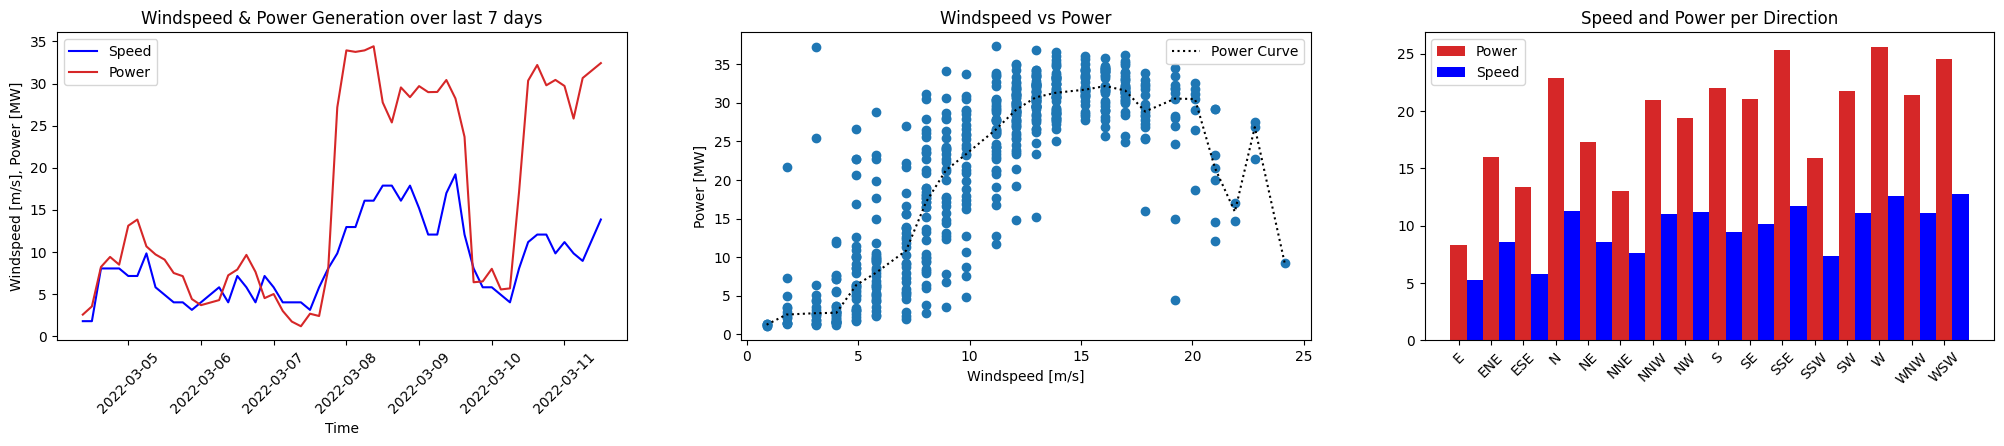

In [20]:
# Subplots
fig, ax = plt.subplots(1,3, figsize=(25,4))

# Speed and Power for the last 7 days
ax[0].plot(joined_dfs["Speed"].tail(int(7*24/3)), label="Speed", color="blue") # Since the datasets are joined every three hours, we need the last 7 days times 24 hours diveded by 3 hours
ax[0].plot(joined_dfs["Total"].tail(int(7*24/3)), label="Power", color="tab:red") # Since the datasets are joined every three hours, we need the last 7 days times 24 hours diveded by 3 hours
ax[0].set_title("Windspeed & Power Generation over last 7 days")
ax[0].set_xlabel("Time")
ax[0].tick_params(axis='x', labelrotation = 45)
ax[0].set_ylabel("Windspeed [m/s], Power [MW]")
ax[0].legend()

# Speed vs Total (Power Curve nature)
ax[1].scatter(joined_dfs["Speed"], joined_dfs["Total"])
power_curve = joined_dfs.groupby("Speed").median(numeric_only=True)["Total"]
ax[1].plot(power_curve.index, power_curve.values, "k:", label="Power Curve")
ax[1].legend()
ax[1].set_title("Windspeed vs Power")
ax[1].set_ylabel("Power [MW]")
ax[1].set_xlabel("Windspeed [m/s]")

# Speed and Power per Wind Direction
wind_grouped_by_direction = joined_dfs.groupby("Direction").mean(numeric_only=True).reset_index()
bar_width = 0.5
x = np.arange(len(wind_grouped_by_direction.index))

ax[2].bar(x, wind_grouped_by_direction.Total, width=0.5, label="Power", color="tab:red")
ax[2].bar(x + bar_width, wind_grouped_by_direction.Speed, width=0.5, label="Speed", color="blue")
ax[2].legend()
ax[2].set_xticks(x)
ax[2].set_xticklabels(wind_grouped_by_direction.Direction)
ax[2].tick_params(axis='x', labelrotation = 45)
ax[2].set_title("Speed and Power per Direction");

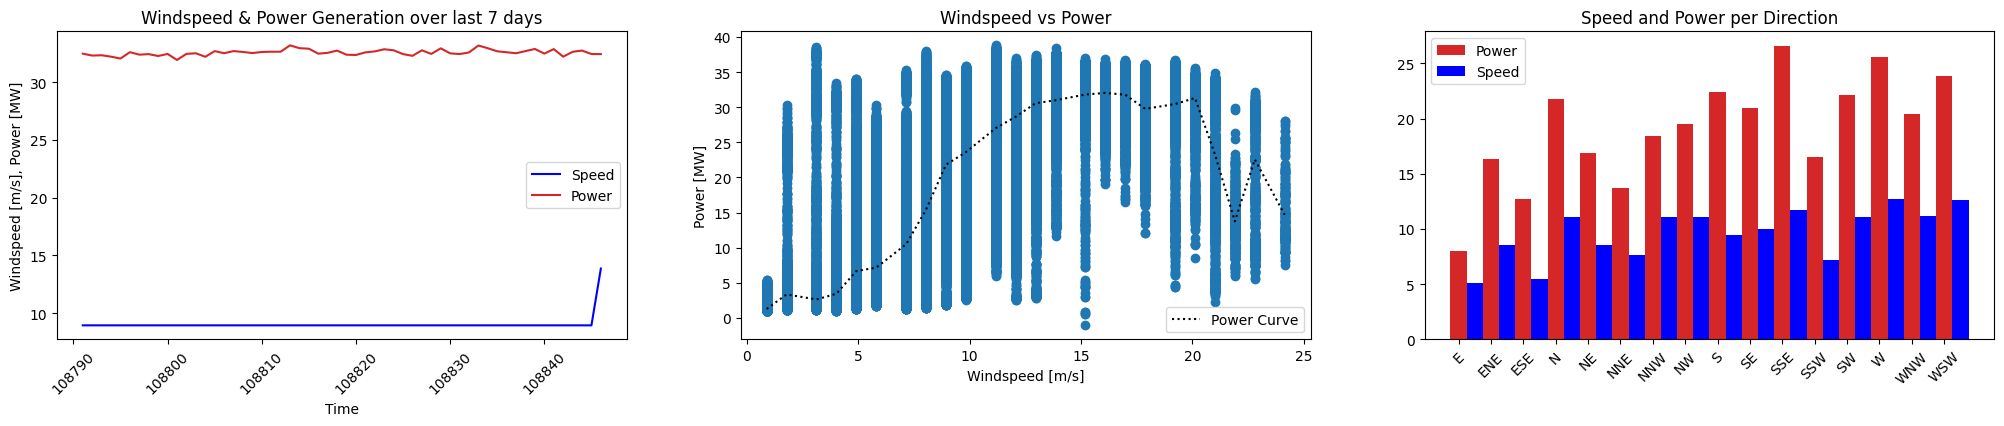

In [21]:
# Subplots
fig, ax = plt.subplots(1,3, figsize=(25,4))

# Speed and Power for the last 7 days
ax[0].plot(data_1min["Speed"].tail(int(7*24/3)), label="Speed", color="blue") # Since the datasets are joined every three hours, we need the last 7 days times 24 hours diveded by 3 hours
ax[0].plot(data_1min["Total"].tail(int(7*24/3)), label="Power", color="tab:red") # Since the datasets are joined every three hours, we need the last 7 days times 24 hours diveded by 3 hours
ax[0].set_title("Windspeed & Power Generation over last 7 days")
ax[0].set_xlabel("Time")
ax[0].tick_params(axis='x', labelrotation = 45)
ax[0].set_ylabel("Windspeed [m/s], Power [MW]")
ax[0].legend()

# Speed vs Total (Power Curve nature)
ax[1].scatter(data_1min["Speed"], data_1min["Total"])
power_curve = data_1min.groupby("Speed").median(numeric_only=True)["Total"]
ax[1].plot(power_curve.index, power_curve.values, "k:", label="Power Curve")
ax[1].legend()
ax[1].set_title("Windspeed vs Power")
ax[1].set_ylabel("Power [MW]")
ax[1].set_xlabel("Windspeed [m/s]")

# Speed and Power per Wind Direction
wind_grouped_by_direction = data_1min.groupby("Direction").mean(numeric_only=True).reset_index()
bar_width = 0.5
x = np.arange(len(wind_grouped_by_direction.index))

ax[2].bar(x, wind_grouped_by_direction.Total, width=0.5, label="Power", color="tab:red")
ax[2].bar(x + bar_width, wind_grouped_by_direction.Speed, width=0.5, label="Speed", color="blue")
ax[2].legend()
ax[2].set_xticks(x)
ax[2].set_xticklabels(wind_grouped_by_direction.Direction)
ax[2].tick_params(axis='x', labelrotation = 45)
ax[2].set_title("Speed and Power per Direction");

These plots should already give us an intuition of the different relationships between features. There is a clear relationship between the wind speed and the power generation from the turbines. But that relationship is not completely linear. Which plot shows that? Finally, it seems like the power generation also depends of where the wind is coming from. Maybe this could also be a useful feature.

In order to plot the relationship between wind speed and power generation we have performed a very simple join with the two datasets. But since the intervals are not the same, a lot of data is discarded (can you spot where in the code this happens?). 

## Power vs Wind Speed
low wind → no power

medium wind → power rises fast

high wind → saturation

--> Should create the S-shaped curve

<Axes: xlabel='Speed', ylabel='Total'>

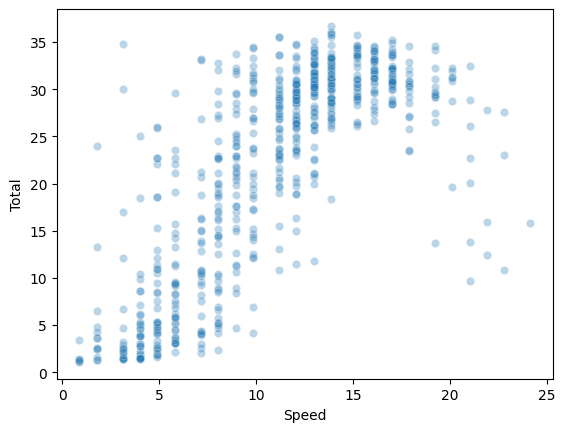

In [22]:
sns.scatterplot(data=data_3hrs, x="Speed", y="Total", alpha=0.3)

<Axes: xlabel='Speed', ylabel='Total'>

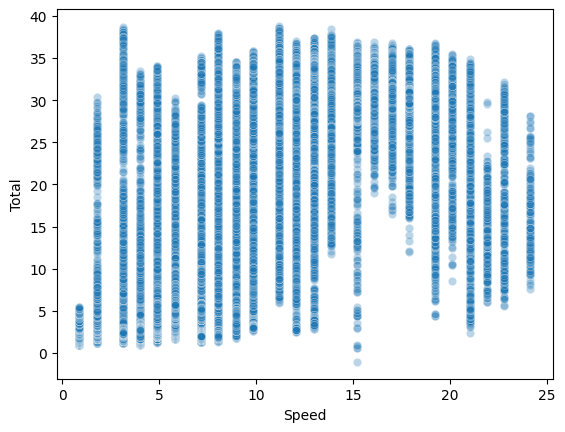

In [23]:
sns.scatterplot(data=data_1min, x="Speed", y="Total", alpha=0.3)
# too many (and noisy) values

### Power vs Wind Direction

<Axes: xlabel='u', ylabel='Total'>

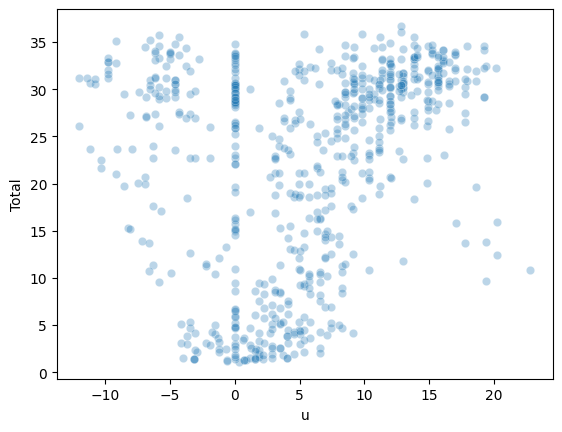

In [24]:
sns.scatterplot(data=data_3hrs, x="u", y="Total", alpha=0.3)

<Axes: xlabel='v', ylabel='Total'>

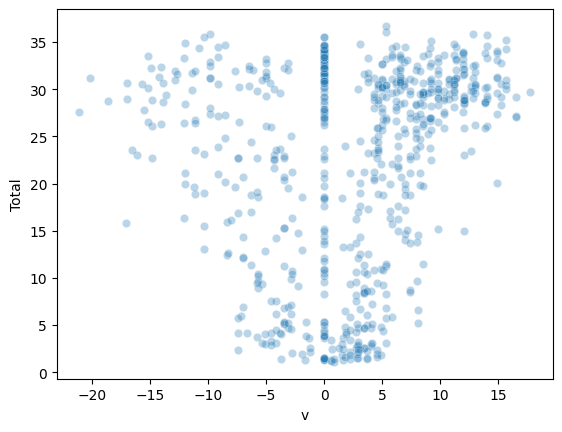

In [25]:
sns.scatterplot(data=data_3hrs, x="v", y="Total", alpha=0.3)

### Binned Power Curve

Shows turnine physics

/tmp/ipykernel_3811/794898680.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  power_curve = data_3hrs.groupby("speed_bin")["Total"].mean()


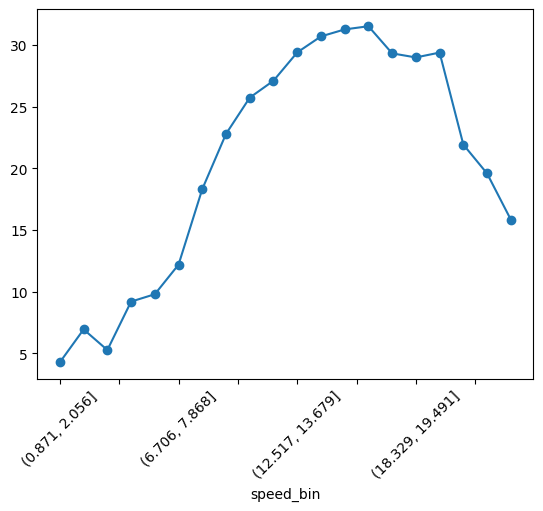

In [26]:
data_3hrs["speed_bin"] = pd.cut(data_3hrs["Speed"], bins=20)

power_curve = data_3hrs.groupby("speed_bin")["Total"].mean()

power_curve.plot(marker='o')
plt.xticks(rotation=45);

In [27]:
data_3hrs.groupby("speed_bin")["Total"].count()

/tmp/ipykernel_3811/3965008738.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_3hrs.groupby("speed_bin")["Total"].count()


speed_bin
(0.871, 2.056]      19
(2.056, 3.219]      19
(3.219, 4.381]      32
(4.381, 5.543]      38
(5.543, 6.706]      38
(6.706, 7.868]      31
(7.868, 9.03]       83
(9.03, 10.193]      37
(10.193, 11.355]    47
(11.355, 12.517]    60
(12.517, 13.679]    65
(13.679, 14.842]    56
(14.842, 16.004]    33
(16.004, 17.166]    67
(17.166, 18.329]    17
(18.329, 19.491]    13
(19.491, 20.653]     7
(20.653, 21.816]     7
(21.816, 22.978]     6
(22.978, 24.14]      1
Name: Total, dtype: int64

In [4]:
data_3hrs

,time,Direction,Lead_hours,Source_time,Speed,ANM,Non-ANM,Total
0,2021-12-11 15:00:00+00:00,SSE,1,1639227600,11.17600,10.956392,16.664656,27.621048
1,2021-12-11 18:00:00+00:00,SSW,1,1639238400,8.04672,6.927587,14.207956,21.135542
2,2021-12-11 21:00:00+00:00,WSW,1,1639249200,11.17600,6.049698,14.566511,20.616209
3,2021-12-12 00:00:00+00:00,WSW,1,1639260000,8.94080,6.254031,14.969844,21.223876
4,2021-12-12 03:00:00+00:00,SW,1,1639270800,9.83488,5.597203,13.821100,19.418303
...,...,...,...,...,...,...,...,...
711,2022-03-10 21:00:00+00:00,S,1,1646938800,9.83488,13.479095,16.532500,30.011595
712,2022-03-11 00:00:00+00:00,SSE,1,1646949600,11.17600,11.358839,16.027783,27.386623
713,2022-03-11 03:00:00+00:00,SSE,1,1646960400,9.83488,10.578812,16.375617,26.954428
714,2022-03-11 06:00:00+00:00,SSE,1,1646971200,8.94080,14.853095,17.115217,31.968312


In [29]:
power_df.isna().sum()

time     0
Total    0
dtype: int64

In [30]:
data_3hrs.isna().sum()

time         0
Direction    0
Speed        0
u            0
v            0
Total        0
speed_bin    0
dtype: int64

### Time dependence

Wind power is autocorrelated !!!!!

Autocorrelation here checks whether past values influence future values

So for wind power: Total(t) ~ Total(t-1)

Meaning:

- If power is high now, it will likely be high soon

- Wind systems move gradually, not randomly

So real wind power data usually shows a plot like:

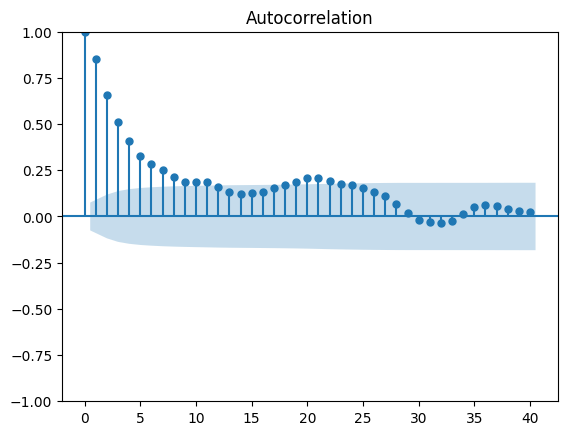

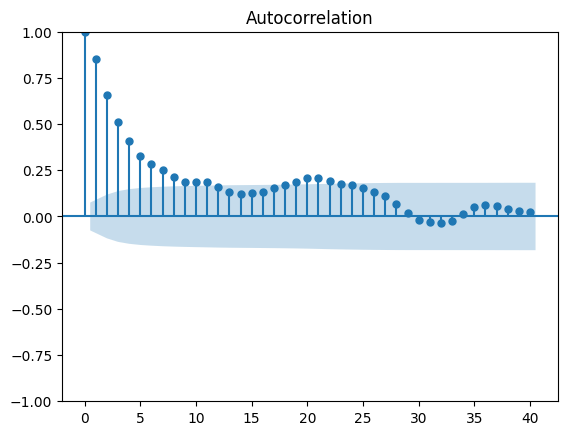

In [31]:
plot_acf(data_3hrs["Total"].dropna(), lags=40)

### Daily / Weekly Patterns

Check if wind varies by hour

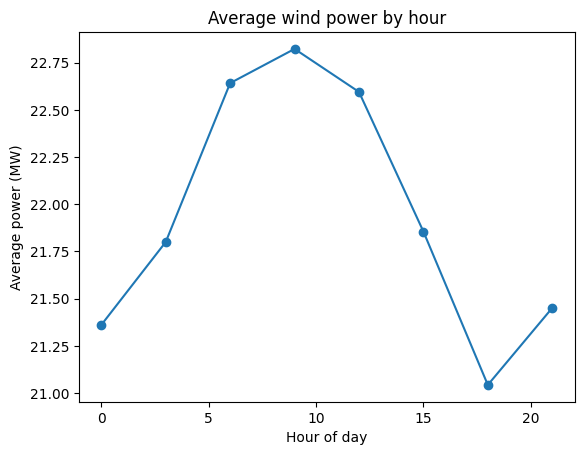

In [32]:
data_3hrs["hour"] = data_3hrs["time"].dt.hour

data_3hrs.groupby("hour")["Total"].mean().plot(marker="o")
plt.title("Average wind power by hour")
plt.xlabel("Hour of day")
plt.ylabel("Average power (MW)")
plt.show()
# daily pattern present

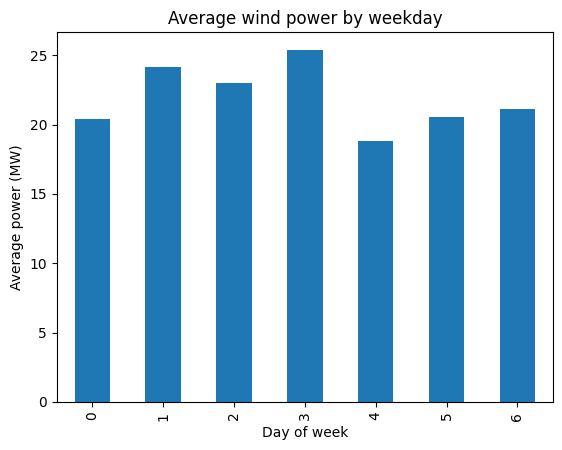

In [33]:
data_3hrs["weekday"] = data_3hrs["time"].dt.dayofweek

data_3hrs.groupby("weekday")["Total"].mean().plot(kind="bar")
plt.title("Average wind power by weekday")
plt.xlabel("Day of week")
plt.ylabel("Average power (MW)")
plt.show()
# no weekly patterns

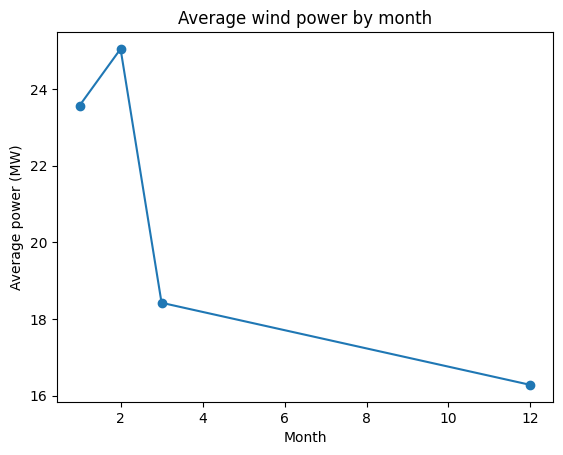

In [34]:
data_3hrs["month"] = data_3hrs["time"].dt.month

data_3hrs.groupby("month")["Total"].mean().plot(marker="o")
plt.title("Average wind power by month")
plt.xlabel("Month")
plt.ylabel("Average power (MW)")
plt.show()

In [35]:
data_3hrs['month'].value_counts()
# we have data just from December to March - this seasonal - monthly - pattern can be mislaeading then

month
1     235
2     221
12    139
3      81
Name: count, dtype: int64

In [36]:
### TODO -> DO SOME EXTRA EDA ON THE DATA ###


## Train-test split of the data

### Time-based Split

In [4]:
# Assume `data_model` is your aligned and cleaned dataset
data_3hrs = data_3hrs.sort_values("time").reset_index(drop=True)

# data_3hrs["hour"] = data_3hrs["time"].dt.hour

# data_3hrs["hour_sin"] = np.sin(2 * np.pi * data_3hrs["hour"] / 24)
# data_3hrs["hour_cos"] = np.cos(2 * np.pi * data_3hrs["hour"] / 24)

# data_3hrs["wind_speed_cubed"] = data_3hrs["Speed"]**3
# data_3hrs = data_3hrs.drop(['Direction', 'Speed', 'index_x', 'index_y', 'hour', 'month', 'weekday', 'time', 'speed_bin'], axis = 1, errors = 'ignore')

# hold out a final test - test set, which is never used during model training
split_idx = int(len(data_3hrs) * 0.8)

train_val_df = data_3hrs.iloc[:split_idx]
test_df  = data_3hrs.iloc[split_idx:]

# Separate features / target
# and we also use TimeSeriesSplit on training data
X_train = train_val_df.drop(columns=["Total"])  # features
y_train = train_val_df["Total"]                 # target

X_test  = test_df.drop(columns=["Total"])
y_test  = test_df["Total"]

tscv = TimeSeriesSplit(n_splits=5)

tscv.split(X_train)
# how should i implement it , where
# i don"t have to split the target varibale, y_train? then how do i knwo which values from the spicfic fold in X correspond to the proper values in y
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

In [9]:
data_3hrs

,time,Direction,Lead_hours,Source_time,Speed,ANM,Non-ANM,Total
0,2021-12-11 15:00:00+00:00,SSE,1,1639227600,11.17600,10.956392,16.664656,27.621048
1,2021-12-11 18:00:00+00:00,SSW,1,1639238400,8.04672,6.927587,14.207956,21.135542
2,2021-12-11 21:00:00+00:00,WSW,1,1639249200,11.17600,6.049698,14.566511,20.616209
3,2021-12-12 00:00:00+00:00,WSW,1,1639260000,8.94080,6.254031,14.969844,21.223876
4,2021-12-12 03:00:00+00:00,SW,1,1639270800,9.83488,5.597203,13.821100,19.418303
...,...,...,...,...,...,...,...,...
671,2022-03-10 21:00:00+00:00,S,1,1646938800,9.83488,13.479095,16.532500,30.011595
672,2022-03-11 00:00:00+00:00,SSE,1,1646949600,11.17600,11.358839,16.027783,27.386623
673,2022-03-11 03:00:00+00:00,SSE,1,1646960400,9.83488,10.578812,16.375617,26.954428
674,2022-03-11 06:00:00+00:00,SSE,1,1646971200,8.94080,14.853095,17.115217,31.968312


## Pipeline and data transformations

Now that we have our data, we need to construct the pipeline to process this data and pass it to our Machine Learning model. For this, use the Pipeline class from Scikit-Learn.

This class applies a list of transformations to your data, and pass the final state to an estimator (your model). Intermediate steps of the pipeline must be ‘transforms’, that is, they must implement fit and transform methods. The final estimator only needs to implement fit.

You can find more information about Scikit-Learn's Pipeline [here](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html).

**Example**

### Helper functions

In [5]:
class FeatureEngineering(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):

        X = X.copy()

        # wind direction → u,v
        compass_to_deg = {
            "N":0,"NNE":22.5,"NE":45,"ENE":67.5,
            "E":90,"ESE":112.5,"SE":135,"SSE":157.5,
            "S":180,"SSW":202.5,"SW":225,"WSW":247.5,
            "W":270,"WNW":292.5,"NW":315,"NNW":337.5
        }

        if "Direction" in X.columns:
            X["angle"] = X["Direction"].map(compass_to_deg)
            X["angle"] = np.deg2rad(X["angle"])

            X["u"] = -X["Speed"] * np.sin(X["angle"])
            X["v"] = -X["Speed"] * np.cos(X["angle"])

        # wind speed cubed
        if "Speed" in X.columns:
            X["wind_speed_cubed"] = X["Speed"]**3

        # time features
        if "time" in X.columns:
            hour = pd.to_datetime(X["time"]).dt.hour
            X["hour_sin"] = np.sin(2*np.pi*hour/24)
            X["hour_cos"] = np.cos(2*np.pi*hour/24)

        # drop unused columns
        drop_cols = ["Direction", "Speed", "angle", "time", "Lead_hours", "Source_time", "ANM", "Non-ANM"]
        X = X.drop(columns=[c for c in drop_cols if c in X.columns])

        return X

class InterpolateData(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):

        # ensure DataFrame
        X = pd.DataFrame(X)

        # interpolate numeric columns
        X = X.interpolate(method="linear", limit_direction="both")

        return X
    

class Imputer(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        self.means_ = X.mean(numeric_only=True)
        return self

    def transform(self, X):
        X = X.copy()
        return X.fillna(self.means_)
    

In [6]:
# models = [
#   {
#     "name": "LinearRegression",
#     "max_degree": 9
#   },
#   {
#     "name": "KNeighborsRegressor",
#     "max_degree": 2
#   },
#   {
#     "name": "GradientBoostingRegressor",
#     "max_degree": 2
#   },
#   {"name": "RandomForestRegressor",
#    "max_degree": _
#   }
# ]

models = {
    "LinearRegression": LinearRegression(),
    "KNN": KNeighborsRegressor(),
    "RandomForest": RandomForestRegressor(random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42)
}

In [ ]:
tscv = TimeSeriesSplit(n_splits=5)

metrics = {
    "MAE": mean_absolute_error,
    "MSE": mean_squared_error,
    "RMSE": lambda y, p: np.sqrt(mean_squared_error(y, p)),
    "R2": r2_score,
    "ExplainedVariance": explained_variance_score
}

results = {}

for name, model in models.items():

    # create storage for all metrics
    fold_scores = {metric: [] for metric in metrics}

    pipe = Pipeline([
        ("features", FeatureEngineering()),
        ("interpolate", InterpolateData()),
        ("imputer", Imputer()),
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    for train_idx, val_idx in tscv.split(X_train):

        X_tr = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]

        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        pipe.fit(X_tr, y_tr)

        preds = pipe.predict(X_val)

        # compute all metrics
        for metric_name, metric_func in metrics.items():
            score = metric_func(y_val, preds)
            fold_scores[metric_name].append(score)

        

    # average across folds
    results[name] = {
        metric: np.mean(scores)
        for metric, scores in fold_scores.items()
    }

print(results)

{'LinearRegression': {'MAE': np.float64(9.474963726313131), 'MSE': np.float64(147.99134264263026), 'RMSE': np.float64(11.513617566697828), 'R2': np.float64(-0.5921604255834932), 'ExplainedVariance': np.float64(-0.16392704615203718)}, 'KNN': {'MAE': np.float64(6.43133807406444), 'MSE': np.float64(74.06642398864793), 'RMSE': np.float64(8.297602150139499), 'R2': np.float64(0.20830154330727524), 'ExplainedVariance': np.float64(0.4172748494954801)}, 'RandomForest': {'MAE': np.float64(4.681542206246001), 'MSE': np.float64(43.39989466389282), 'RMSE': np.float64(6.4771249370297195), 'R2': np.float64(0.49715076700381056), 'ExplainedVariance': np.float64(0.5482610324144205)}, 'GradientBoosting': {'MAE': np.float64(4.791294600852909), 'MSE': np.float64(44.78128243864246), 'RMSE': np.float64(6.572308484190512), 'R2': np.float64(0.488384659219384), 'ExplainedVariance': np.float64(0.5429410885548054)}}


In [ ]:
best_model = min(results, key=lambda m: results[m]["RMSE"])

print("Best model:", best_model)
print("Scores:", results[best_model])

results_df = pd.DataFrame(results).T
print(results_df.sort_values("RMSE"))

                       MAE      RMSE
RandomForest      4.665433  6.455793
GradientBoosting  4.877983  6.656136
LinearRegression  5.948305  9.190068
KNN               7.182543  9.009715

Best model: RandomForest
MAE: 4.6654332883088845
RMSE: 6.455793202367613


### Evaluate your model

Now that you have a preprocessing pipeline ready, along with the final estimator, you may want to know how well your model performs. Choose the method you prefer, with special attention to the selected metric.

**Example**

Let's see how our predictions look compared to the true values.

In [44]:
# predictions = pipeline_example.predict(X_test)

# plt.figure(figsize=(15, 4))
# plt.plot(np.arange(len(predictions)), predictions, label="Predictions")
# plt.plot(np.arange(len(y_test)), y_test, label="Truth")
# plt.legend()
# plt.show()


HINT: Pay special attention to this type of data: We are dealing with Time series data (i.e. data that is recorded over consistent intervals of time). It might be a good idea not to randomly split the data, since it wouldn't respect the temporal order and may cause data-leakage, unintentionally inferring the trend of future samples.

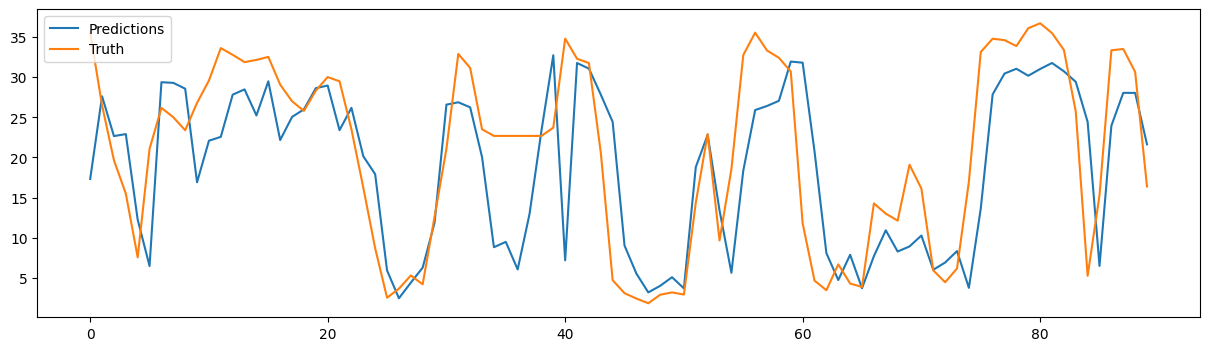

In [45]:
# Use your preferred method to evaluate your model
plt.figure(figsize=(15, 4))
plt.plot(np.arange(len(preds)), preds, label="Predictions")
plt.plot(np.arange(len(y_val)), y_val, label="Truth")
plt.legend()
plt.show()


## Tracking your experiments with MLFlow
We have a working model with a certain accuracy. But wouldn't it be better to try different parameters and different models before deciding for one?

This is exactly what we will do using the MLFlow library. MLflow is an open source platform to manage the ML lifecycle, including experimentation, reproducibility, deployment, and a central model registry. This will allow us for easy comparison of all our model experiments.

Example
When using MLFlow locally to log our experiments, we need to start a "local server". We can do this easily by running the following in our command line interface (in the Terminal):

```
mlflow server --host 127.0.0.1 --port 5000
```

Once you start the server you will see the following information in the Terminal: `Uvicorn running on http://127.0.0.1:5000`.

The server is located at our localhost `127.0.0.1, port 5000`. We will use this information to indicate where our experiment logs will be shown.

In [46]:
# Start an MLflow run
mlflow.sklearn.autolog() # This is to help us track scikit learn metrics.
mlflow.set_tracking_uri("http://127.0.0.1:5000") # We set the MLFlow UI to display in our local host.

# Set the experiment and run name
experiment_name = "LinearRegression-Example" # Think how to best organise experiments - for example by model type
run_name = "Simple_regression" # Give explicit names 

mlflow.set_experiment(experiment_name)

with mlflow.start_run(run_name=run_name) as run:
    
    # Train our model
    pipeline_example.fit(X_train, y_train)

    # Evaluate the model, using MAE as a metric
    predictions = pipeline_example.predict(X_test)
    mae = mean_absolute_error(predictions, y_test)

    mlflow.log_metric("MAE", mae)

MlflowException: API request to http://127.0.0.1:5000/api/2.0/mlflow/experiments/get-by-name failed with exception HTTPConnectionPool(host='127.0.0.1', port=5000): Max retries exceeded with url: /api/2.0/mlflow/experiments/get-by-name?experiment_name=LinearRegression-Example (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x7d4ba5795f10>: Failed to establish a new connection: [Errno 111] Connection refused'))

In the example above you can see that:
- we are using `sklearn.autolog()` to automatically log `scikit-learn` specific metrics
- we set an experiment_name; if the experiment doesn't exist it will create a new one, otherwise it will use the already existent experiment
- we set a run_name; same as above
- after model training we record the MAE to compare between runs

Click on either of the links above to see your experiments. Have a look at the Overview, Model metrics, and Artifacts.

Now have a look at the *Explorer* tab on the left and notice the newly created files and folders: 
- `mlflow.db` - a database containing metadata regarding experiments, runs, and parameters that you logged
- `mlartifacts/` folders
    - each folder will correspond to a run
    - the `models` folder contains data about the logged models, such as the envinroment file, a .pkl file containing the model, and a MLmodel complete description of the model; have a look at each of those

Now try out different set-ups. You can experiment with different pre-processing steps, models, and parameters. If you need a tutorial on MLflow Tracking you can find one [here](https://mlflow.org/docs/latest/ml/tracking/).

In [ ]:
### TODO -> SET YOUR OWN EXPERIMENT SETUP ###
# Here, you may want to stop and think what is the best way to iterate(!) through all the models and experiments you want to try. 
# Instead of running your code everytime you want to change something, you could try to list all your desired experiments and run them all sequentially in one go (gridsearch style).


# Define models
experiments = {
    "RandomForest": {
        "model": RandomForestRegressor,
        "params": {
            "n_estimators": [100, 200, 300],
            "max_depth": [10, 20, 30],
            "min_samples_split": [2, 5]
        }
    },

    "GradientBoosting": {
        "model": GradientBoostingRegressor,
        "params": {
            "n_estimators": [100, 200],
            "learning_rate": [0.01, 0.1],
            "max_depth": [3, 5]
        }
    },

    "KNN": {
        "model": KNeighborsRegressor,
        "params": {
            "n_neighbors": [3, 5, 7]
        }
    },

    "LinearRegression": {
        "model": LinearRegression,
        "params": {}
    }
}

# Time series split
tscv = TimeSeriesSplit(n_splits=5)

# Set MLflow experiment
mlflow.set_experiment("WindPowerForecasting")

results = {}

for model_name, config in experiments.items():

    for params in ParameterGrid(config["params"]):

        model = config["model"](**params)

        run_name = f"{model_name}_{params}"
        with mlflow.start_run(run_name=run_name):

            pipe = Pipeline([
                ("features", FeatureEngineering()),
                ("interpolate", InterpolateData()),
                ("imputer", Imputer()),
                ("scaler", StandardScaler()),
                ("model", model)
            ])

            # metric storage
            fold_mae = []
            fold_rmse = []
            fold_mse = []
            fold_r2 = []
            fold_ev = []

            for train_idx, val_idx in tscv.split(X_train):

                X_tr = X_train.iloc[train_idx]
                X_val = X_train.iloc[val_idx]

                y_tr = y_train.iloc[train_idx]
                y_val = y_train.iloc[val_idx]

                pipe.fit(X_tr, y_tr)

                preds = pipe.predict(X_val)

                mae = mean_absolute_error(y_val, preds)
                mse = mean_squared_error(y_val, preds)
                rmse = np.sqrt(mse)
                r2 = r2_score(y_val, preds)
                ev = explained_variance_score(y_val, preds)

                fold_mae.append(mae)
                fold_mse.append(mse)
                fold_rmse.append(rmse)
                fold_r2.append(r2)
                fold_ev.append(ev)

            # average metrics
            cv_mae = np.mean(fold_mae)
            cv_mse = np.mean(fold_mse)
            cv_rmse = np.mean(fold_rmse)
            cv_r2 = np.mean(fold_r2)
            cv_ev = np.mean(fold_ev)

            # log to MLflow
            mlflow.log_metric("CV_MAE", cv_mae)
            mlflow.log_metric("CV_MSE", cv_mse)
            mlflow.log_metric("CV_RMSE", cv_rmse)
            mlflow.log_metric("CV_R2", cv_r2)
            mlflow.log_metric("CV_ExplainedVariance", cv_ev)

            mlflow.log_params(params)
            mlflow.log_param("model_type", model_name)
            
            # Train final model on ALL training data
            pipe.fit(X_train, y_train)

            # Log trained pipeline
            mlflow.sklearn.log_model(
                sk_model=pipe,
                artifact_path="model"
            )

        # # optionally log model hyperparameters
        # if hasattr(model, "get_params"):
        #     mlflow.log_params(model.get_params())

        

        # store results
        run_key = f"{model_name}_{params}"
        results[run_key] = {
            "MAE": cv_mae,
            "MSE": cv_mse,
            "RMSE": cv_rmse,
            "R2": cv_r2,
            "ExplainedVariance": cv_ev
        }


2026/03/11 16:09:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
/usr/local/python/3.12.1/lib/python3.12/site-packages/mlflow/models/model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format.
  flavor.save_model(path=local_path, mlflow_model=mlflow_model, **kwargs)
2026/03/11 16:09:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
/usr/local/python/3.12.1/lib/python3.12/site-packages/mlflow/models/model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alt

In [17]:
from mlflow.tracking import MlflowClient

client = MlflowClient()
experiment_id = mlflow.get_experiment_by_name("WindPowerForecasting").experiment_id

# List all runs in the experiment
runs = client.search_runs(experiment_ids=[experiment_id])

for run in runs:
    artifacts = client.list_artifacts(run.info.run_id)
    print(run.info.run_id, [a.path for a in artifacts])

0afd737c580a4196971a9aa2ff90a547 []
19293e7e82244ecba7762a71f980f4bc []
536fb6ac93c3472fb19b6835c1a0aa26 []
90b38b178fcd4e1fbcb061f70c2ed990 []
58f0fb63c4234d52ab466290772f3113 []
95e295f2339e46508b2731b91bcf5f79 []
89f40f4914824b56a487e13e3845bcb2 []
18873e9a13a94ac98e39be2ec7d2bd76 []
f95a4908c58c49e98eed64b0d1ce83ef []
f48c755434f34a579f711496c1eef8e9 []
79c91f71db0e42e4808d2aec336ac01b []
0b297d1e03304c34ab78f9181a1edade []
2e7c2cad67044afea7e7bcde17924833 []
7913ac9bcf5e4bffb7652ecd7cddd691 []
0e5a094303344e3489788d4c1c3fdf7e []
64180fd268b748f9809f7e0d724046c4 []
c258a5ed417a424d93a20d8615bc2d83 []
47f2f0b436fe4c8ba4ea8dd3d3af6400 []
18ad85cde4d34ea3ab316d59e8fc4c64 []
78aead6480d34ef6a7c68d9839178d97 []
c728d8085c384caf83676a491ec0dc77 []
c073b567fc0041dba57846eec18e073b []
fa7e11b393934568b18809f15e9b9b78 []
de8979e4e2f6432cac195d2044874504 []
bde225535ef34879bf02e1428405b6e1 []
edeec7d72bde47aebbd15e1c26f9b625 []
1b4d364fc143406c92858083d6b8bc8f []
c09c0052bcb3404d9fb7246d6793

In [12]:
results_df = pd.DataFrame.from_dict(results, orient="index")

print(results_df.sort_values("RMSE"))

                                                         MAE         MSE  \
RandomForest_{'max_depth': 10, 'min_samples_spl...  4.637929   41.796923   
RandomForest_{'max_depth': 10, 'min_samples_spl...  4.653147   41.930224   
RandomForest_{'max_depth': 20, 'min_samples_spl...  4.662649   41.904680   
RandomForest_{'max_depth': 20, 'min_samples_spl...  4.676355   42.050884   
RandomForest_{'max_depth': 30, 'min_samples_spl...  4.686436   42.260482   
RandomForest_{'max_depth': 20, 'min_samples_spl...  4.682737   42.306508   
RandomForest_{'max_depth': 30, 'min_samples_spl...  4.687960   42.353652   
GradientBoosting_{'learning_rate': 0.01, 'max_d...  5.012760   42.340378   
RandomForest_{'max_depth': 30, 'min_samples_spl...  4.700427   42.485334   
RandomForest_{'max_depth': 30, 'min_samples_spl...  4.695609   42.496879   
RandomForest_{'max_depth': 20, 'min_samples_spl...  4.698035   42.762713   
RandomForest_{'max_depth': 10, 'min_samples_spl...  4.727019   42.799160   
RandomForest

In [13]:
print(results_df.sort_values("MAE"))

                                                         MAE         MSE  \
RandomForest_{'max_depth': 10, 'min_samples_spl...  4.637929   41.796923   
RandomForest_{'max_depth': 10, 'min_samples_spl...  4.653147   41.930224   
RandomForest_{'max_depth': 20, 'min_samples_spl...  4.662649   41.904680   
RandomForest_{'max_depth': 20, 'min_samples_spl...  4.676355   42.050884   
RandomForest_{'max_depth': 20, 'min_samples_spl...  4.682737   42.306508   
RandomForest_{'max_depth': 30, 'min_samples_spl...  4.686436   42.260482   
RandomForest_{'max_depth': 10, 'min_samples_spl...  4.687073   42.702666   
RandomForest_{'max_depth': 30, 'min_samples_spl...  4.687960   42.353652   
RandomForest_{'max_depth': 30, 'min_samples_spl...  4.695609   42.496879   
RandomForest_{'max_depth': 20, 'min_samples_spl...  4.698035   42.762713   
RandomForest_{'max_depth': 30, 'min_samples_spl...  4.699741   42.851250   
RandomForest_{'max_depth': 30, 'min_samples_spl...  4.700427   42.485334   
RandomForest

In [14]:
best_model = results_df["RMSE"].idxmin()

print("\nBest configuration:")
print(best_model)
print(results_df.loc[best_model])


Best configuration:
RandomForest_{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 300}
MAE                   4.637929
MSE                  41.796923
RMSE                  6.383816
R2                    0.518517
ExplainedVariance     0.568117
Name: RandomForest_{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 300}, dtype: float64


In [15]:
print(results_df.sort_values("RMSE").head())

results_df.to_csv("experiment_results.csv")

                                                         MAE        MSE  \
RandomForest_{'max_depth': 10, 'min_samples_spl...  4.637929  41.796923   
RandomForest_{'max_depth': 10, 'min_samples_spl...  4.653147  41.930224   
RandomForest_{'max_depth': 20, 'min_samples_spl...  4.662649  41.904680   
RandomForest_{'max_depth': 20, 'min_samples_spl...  4.676355  42.050884   
RandomForest_{'max_depth': 30, 'min_samples_spl...  4.686436  42.260482   

                                                        RMSE        R2  \
RandomForest_{'max_depth': 10, 'min_samples_spl...  6.383816  0.518517   
RandomForest_{'max_depth': 10, 'min_samples_spl...  6.389239  0.516715   
RandomForest_{'max_depth': 20, 'min_samples_spl...  6.394136  0.516607   
RandomForest_{'max_depth': 20, 'min_samples_spl...  6.402727  0.514271   
RandomForest_{'max_depth': 30, 'min_samples_spl...  6.419036  0.512851   

                                                    ExplainedVariance  
RandomForest_{'max_depth': 10, '

### Comparing models

Suppose you have ran some experiments, trying different pre-processing steps, models, and parameters. To easily compare the results from our experiments, we can use the MLFlow interface.

**Example.**
We have been logging our experiments in our local server. We can access the UI by opening the localhost address in any browser. You should see a list of all the experiments under *Experiments*. When logging multiple runs with different parameters/metrics, you will be able to easily compare them using the "Chart View". Make sure to try this out.

## Registering the best model

Now suppose you have tried many different models with different parameters, you might want to register the best one. To do this, we can use again the UI. You can follow the instructions below or this [visual guide](register_model_guide.pdf) which you can open in the repository:

- In the Experiments list, select the name of the experiment you want. 
- Click Models in the left panel.
- Click on the model you want to use, in this case it's named "model"
- Then "Register Model".
- First "Select a model", click "Create New Model" and name it "LinearRegression"

Now, if you go to the Homepage, on the "Models" tab, you will see that you registered the model.

In case of doubt, you can check the [documentation](https://mlflow.org/docs/latest/ml/model-registry/tutorial/).

**Using a registered model**

Now that we have registered our best model, we can use it for future predictions. We can retrieve the weather forecasts for the next days, and make predictions of power generation.

**Example.**
First we need the new forecast data:

In [ ]:
future_df = pd.read_csv("data/future.csv")
future_df["time"] = pd.to_datetime(future_df["time"], utc=True)
future_df["Source_time"] = pd.to_datetime(future_df["Source_time"], unit="s", utc=True)

Then, we can retrieve any saved model and use it to predict on the new data:

In [ ]:
model_name = "LinearRegression"
model_version = 1

model_uri = f"models:/{model_name}/{model_version}"
model = mlflow.pyfunc.load_model(model_uri=model_uri)

X_forecast = future_df[["Speed"]]
predictions = model.predict(X_forecast)

predictions_df = future_df[["Speed"]].copy()
predictions_df["Predicted_Power"] = predictions

print(predictions_df.head())

## Serving your model

So far, we have trained several models and registered the best one. Often times, we will want to deploy the best model in such a way that other people can take advantage of it, by sending a request with data and getting back predictions. In this project you will only serve the model locally, a step usually done before deployment to ensure that the model works as expected. 

Serving a model refers to the process of making a trained machine learning model available to receive input data and provide predictions or inferences based on that data. In other words, when you serve a model, you set it up in a way that it can be queried with new data, and it will produce predictions or outputs based on the patterns it learned during training.

Serving a model is a critical step in the machine learning lifecycle, as it allows you to leverage the model's predictive capabilities in real-world applications. When a model is served, it becomes accessible to applications, websites, or other systems that need to utilize its predictions.

You have tried serving the model in [one of the previous exercises](https://github.com/LSDA-BDM/exercise-mlflow-caiso). Run the same command to serve your current model.

> Note. The current configuration is slightly different that in the exercise. You won't have to call `mlflow run .` as in the exercise. Do you know why? However, before serving the model, you will have to set the tracking URI in the terminal with:
> ```bash
> export MLFLOW_TRACKING_URI=http://localhost:5000
> ```

Serve the model and then use `curl` to test that it worked.

## Packaging your project

Lastly, we want to make sure that others are able to run the project and do further development. As opposed to just making the model available as before (with serving) now you will package the project in order to make it reproducible.

Reproducibility refers to the ability of researchers, developers, and practitioners to recreate the exact same results, analyses, and outcomes from a given set of source code and data. In that sense, MLflow Projects is a standardized way to encapsulate an experiment in a reproducible
manner, so colleagues or other stakeholders can reproduce your code. This is done by specifying all the dependencies using a 'pip' environment file, a 'conda' environment file, or a docker environment. Here we will take the ‘pip‘ approach.

An MLflow project consists (at least) of:

- The code you want to package, including the data for your experiments (if needed). Jupyter Notebooks are not supported, so you will have to more the relevant code in `.py` file; you can check the `script.py` file provided for an example.
- A requirements.txt file specifying the dependencies for the code (in this case a text file with ‘pip‘-installable dependencies).
- An MLproject file specifying which environment file to use, parameters accepted, and the entry points to the code.

First, try to run the script `script.py` with

```bash
python script.py
```
> Note: For this to run you must have started an mlflow server as shown in Tracking your experiments.

Then, create a similar script containing your experiments; also create the other files necessary for an MLProject. Have a look at [this exercise](https://github.com/LSDA-BDM/exercise-polynomial/) that explains how MLflow projects work.

## Notes and hints

Here are a few resources you can use to inform your design decisions for your experiments:

**Joining the data.** How do you join and align the data will affect the amount of data you end up with for training your model. Make sure you explain your decision and reflect upon its pros and cons. Some resources for pandas: [Join](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.join.html), [Merge](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.merge.html), [Resample](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.resample.html).

**Wind direction encoding.** You will most likely need to transform the wind direction into a numerical feature. Some possibilities to consider, make sure you reflect on their advantages and disadvantages:
- [OneHotEncoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html)
- Transforming to degrees or radians with a [custom transformer](https://towardsdatascience.com/pipelines-custom-transformers-in-scikit-learn-ef792bbb3260/)
- Converting speed and direction to a [2-dimensional vector](https://www.tensorflow.org/tutorials/structured_data/time_series#wind)

**Scaling.** Think what is the range of your features. Is your model affected by this? Should you scale your features? You should explain why would you do it, or why it's not necessary. Check [Scikit-Learn's Preprocessing and Normalization](https://scikit-learn.org/stable/modules/preprocessing.html#standardization-or-mean-removal-and-variance-scaling) or this [article](https://www.geeksforgeeks.org/ml-feature-scaling-part-2/).

**Feature transformations.** If you want to apply different transformations to different columns (e.g. categorical and numerical), you can use the [ColumnTransformer](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html).

**Missing values.** Check [Scikit-Learn’s imputers](https://scikit-learn.org/stable/modules/impute.html) to see different options for dealing with missing values. 

**Splitting and shuffling.** You are working with time series data. Is it acceptable to do a random shuffle on the data when splitting for training? If so, why? If not, how can you split the data? Make sure to argue your decision. Check [Scikit-Learn’s TimeSeries Split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html#sklearn.model_selection.TimeSeriesSplit) or this [article](https://machinelearningmastery.com/backtest-machine-learning-models-time-series-forecasting/).